<table class="tfo-notebook-buttons" align="left">
<td style="border: none;">
<a target="blank" href="https://colab.research.google.com/github/Hari31416/Portfolio/blob/main/Titanic/EDA%20and%20Feature%20Engineering.ipynb?hl=en"><img src="https://colab.research.google.com/img/colab_favicon_256px.png" width="28" height="28"/>Run on Google Colab</a></td>
<td style="border: none;">
<a target="blank" href="https://github.com/Hari31416/Portfolio/blob/main/Titanic/EDA%20and%20Feature%20Engineering.ipynb"><img src="https://cdn.icon-icons.com/icons2/2368/PNG/512/github_logo_icon_143772.png" width="28" height="28"/>View on Github</a></td>
<td style="border: none;">
</table>

## Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.offline import download_plotlyjs, init_notebook_mode, plot, iplot
import cufflinks as cf
init_notebook_mode(connected=True)
cf.go_offline()

## Loading the DataFrames and Basic Analysis

In [2]:
train = pd.read_csv('train_cleaned.csv')
test = pd.read_csv('test_cleaned.csv')

In [3]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        891 non-null    object 
 11  Embarked     891 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [4]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    object 
 3   Sex          418 non-null    object 
 4   Age          418 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    object 
 8   Fare         418 non-null    float64
 9   Cabin        418 non-null    object 
 10  Embarked     418 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 36.0+ KB


No null values!

In [5]:
numerical_cols = train.columns[(train.dtypes == np.int64) |(train.dtypes == np.float)]
string_cols = train.columns[train.dtypes == 'object']
print(f"Features with numerical values are: {numerical_cols.values}")
print(f"Features with non-numerical values are: {string_cols.values}")

Features with numerical values are: ['PassengerId' 'Survived' 'Pclass' 'Age' 'SibSp' 'Parch' 'Fare']
Features with non-numerical values are: ['Name' 'Sex' 'Ticket' 'Cabin' 'Embarked']


In [6]:
import matplotlib
matplotlib.rcParams['figure.figsize'] = (8, 6)

## Non-Numeric Features

As we saw, the non-numeric features in the dataframe are: 'Name' 'Sex' 'Ticket' 'Cabin' 'Embarked'. Let's start with *Name*

### Name

Name would not be highly correlated with the desired output. So, we'll be intersted in finding some other features derived from it which might be more useful for our result.

Let's try the first name.

In [7]:
train['Name'].apply(lambda x: x.split(',')[0].strip()).value_counts()

Andersson    9
Sage         7
Johnson      6
Panula       6
Carter       6
            ..
Sloper       1
Lindell      1
Klasen       1
McNamee      1
Kraeff       1
Name: Name, Length: 667, dtype: int64

Not interesting.

Next, let's try the title.

In [8]:
def get_title(name):
    pattern = r"\w+,\s(\w{1,8})\."
    title = re.search(pattern, name)
    if title is None:
        return 'Unknown'
    else:
        return title.group(1)

In [9]:
titles = train["Name"].apply(lambda x: get_title(x)).value_counts()
titles

Mr          517
Miss        182
Mrs         125
Master       40
Dr            7
Rev           6
Mlle          2
Col           2
Major         2
Sir           1
Capt          1
Mme           1
Unknown       1
Don           1
Ms            1
Lady          1
Jonkheer      1
Name: Name, dtype: int64

This seems intersing enough. Since there are a lot of titles, we'll group all the titles with less than 3 characters into one category. Let's call this category `other`.

In [10]:
titles_list = list(titles[titles>3].index)[::-1]
def add_title(name):
    for title in titles_list:
        if title in name:
            return title
    return 'Other'

We'll add a `Title` column to both the dataframes using the above function.

In [11]:
train["Title"] = train["Name"].apply(add_title)
test["Title"] = test["Name"].apply(add_title)

In [12]:
train['Title'].value_counts()

Mr        516
Miss      179
Mrs       128
Master     40
Dr         11
Other      11
Rev         6
Name: Title, dtype: int64

Let's visualize this column.

In [13]:
def hist_by_column(column):
    data_by_column = train[[column, 'Survived']].value_counts().unstack().fillna(0)
    data_by_column.iplot(kind='bar', title=f'Survival by {column}', xTitle=column, 
        yTitle='Number of Passangers', colors=['#a83246', '#32a852'])

In [14]:
hist_by_column("Title")

Let's convert this to show percentages.

In [15]:
train['Title'].value_counts()

Mr        516
Miss      179
Mrs       128
Master     40
Dr         11
Other      11
Rev         6
Name: Title, dtype: int64

In [16]:
def hist_by_column_perc(column):
    data_by_title = train[[column, 'Survived']].value_counts().unstack().fillna(0)
    data_by_title['Total'] = data_by_title.sum(axis = 1)
    data_by_title[0] = data_by_title[0]*100/data_by_title['Total']
    data_by_title[1] = data_by_title[1]*100/data_by_title['Total']
    data_by_title.drop('Total', axis=1, inplace=True)
    data_by_title.iplot(kind='bar', title=f'Survival by {column}', xTitle=column,
        yTitle='Percentage of Passangers', colors=['#a83246', '#32a852'])

In [17]:
hist_by_column_perc("Title")

It is obvious from the plot that being a "Miss", "Mrs." or "Master" is more likely to survive with compared to being a "Mr" or "Dr". What's more, all the passengers with the title "Rev" could not make it. Only about 16% of passangers with "Mr" could survive.

### Sex

For this column, only thing which we need to do is convert this from `object` to `numerical` column. This can be done very easily. 1 corresponds to 'Female' and 0 to 'Male'.

In [18]:
train['Sex'] = train['Sex'].apply(lambda x: 0 if (x == 'male') else 1)
test['Sex'] = test['Sex'].apply(lambda x: 0 if (x == 'male') else 1)

In [19]:
train["Sex"].dtypes, test["Sex"].dtypes

(dtype('int64'), dtype('int64'))

In [20]:
hist_by_column("Sex")

In [21]:
hist_by_column_perc("Sex")

Since class 1 corresponds to female and 0 to male, we see that females are much more likely to survive them males. In fact, only about 19% males were survived where over 74% female were survived.

### Ticket

In [22]:
def get_first_digit(ticket):
    first_char = ticket[0]
    if first_char.isalpha():
        return 'X'
    else:
        return first_char

In [23]:
train['Ticket'].apply(get_first_digit).value_counts()

3    301
X    230
2    183
1    146
4     10
7      9
6      6
5      3
8      2
9      1
Name: Ticket, dtype: int64

Here, again, we'll remove the categories which has less than 3 entries and add them to 'X'. This means, if the first letter of ticket is 5,8 or 9, we'll group that to 'X'.

In [24]:
ticket_first_letter = train['Ticket'].apply(get_first_digit).value_counts().index
ticket_first_letter

Index(['3', 'X', '2', '1', '4', '7', '6', '5', '8', '9'], dtype='object')

In [25]:
def get_ticket_first_letter(ticket):
    for letter in ticket_first_letter[:-3]:
        if letter == ticket[0]:
            return letter
    return 'X'

In [26]:
train["Ticket_first_letter"] = train['Ticket'].apply(get_ticket_first_letter)

In [27]:
test["Ticket_first_letter"] = test['Ticket'].apply(get_ticket_first_letter)

In [28]:
train["Ticket_first_letter"].value_counts()

3    301
X    236
2    183
1    146
4     10
7      9
6      6
Name: Ticket_first_letter, dtype: int64

In [29]:
test["Ticket_first_letter"].value_counts()

3    128
X    123
2     95
1     64
7      4
6      3
4      1
Name: Ticket_first_letter, dtype: int64

In [30]:
hist_by_column("Ticket_first_letter")

In [31]:
hist_by_column_perc("Ticket_first_letter")

It seems that the passangers having ticket number starting with '1' are the most likely to survive, but it can just be a coincidence. However, we can see that as the first letter of ticket increases, the chances of survival decreases. For ticket having first letter an alphabet, the chances of survival is greater (about 38%).

### Cabin

In [32]:
train['Cabin']

0      None
1       C85
2      None
3      C123
4      None
       ... 
886    None
887     B42
888    None
889    C148
890    None
Name: Cabin, Length: 891, dtype: object

We'll just extract the first letter of the cabin and add it to the dataframe.

In [33]:
train['Cabin'].apply(lambda x: x[0]).value_counts()

N    687
C     59
B     47
D     33
E     32
A     15
F     13
G      4
T      1
Name: Cabin, dtype: int64

Again, let's group the "G" and "T" cabins to "C" so that number of different cabins are reduced.

In [34]:
cabin_first = train['Cabin'].apply(lambda x: x[0]).value_counts().index
cabin_first

Index(['N', 'C', 'B', 'D', 'E', 'A', 'F', 'G', 'T'], dtype='object')

In [35]:
def get_cabin_first(cabin):
    for letter in cabin_first[:-2]:
        if letter == cabin[0]:
            return letter
    return 'C'

In [36]:
train["Cabin_First"] = train['Cabin'].apply(get_cabin_first)
test["Cabin_First"] = test['Cabin'].apply(get_cabin_first)

In [37]:
hist_by_column("Cabin_First")

In [38]:
hist_by_column_perc("Cabin_First")

Passangers with a cabin are more likely to survive, the exception is cabin "A" where just 47% of the passangers survived. The survival chances for cabin "B", "D" and "E" are very high, about 75%.

### Embarked

In [39]:
train['Embarked'].value_counts()

S    646
C    168
Q     77
Name: Embarked, dtype: int64

Great! Nothing to do here!

In [40]:
hist_by_column("Embarked")

In [41]:
hist_by_column_perc("Embarked")

Note that :
* C = Cherbourg, 
* Q = Queenstown, 
* S = Southampton

So, those embarked from Cherbourg are more likely to survive than those from Queenstown and Southampton.

## Numeric Features

In [42]:
numerical_cols

Index(['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare'], dtype='object')

### Survived

Even though this is the desired output, we'll use some analysis to see about it's distribution.

In [96]:
train["Survived"].value_counts()

0    549
1    342
Name: Survived, dtype: int64

In [98]:
train["Survived"].value_counts()*100/len(train)

0    61.616162
1    38.383838
Name: Survived, dtype: float64

So, only about 39% of the passangers survived. This means that this classification problem is almost balanced but not perfectly balanced.

### Pclass

In [43]:
train["Pclass"].sort_values().value_counts()

3    491
1    216
2    184
Name: Pclass, dtype: int64

In [44]:
hist_by_column("Pclass")

In [45]:
hist_by_column_perc("Pclass")

As the Pclass decreases, the chances of survival decreases.

### Age

<AxesSubplot:xlabel='Survived', ylabel='Age'>

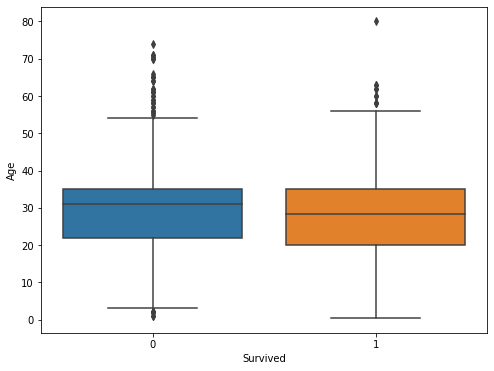

In [46]:
sns.boxplot(x="Survived", y="Age", data=train)

The boxplot doesn't makes things very clear. However, we can see that the mean age of the passangers who survived is less.

<AxesSubplot:ylabel='Age'>

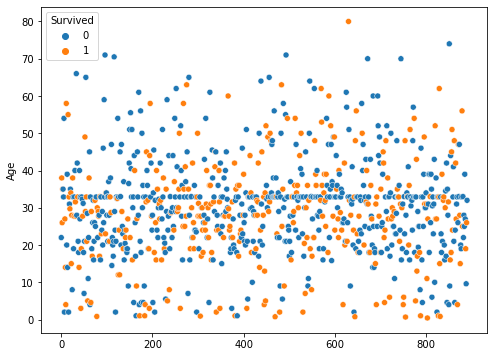

In [47]:
sns.scatterplot(y = train["Age"], x = np.arange(len(train["Age"])), hue = train["Survived"])

Again, not very informative.

In [48]:
train["Age"].iplot(kind='hist', bins=20, xTitle='Age', yTitle='Number of Passangers')

<AxesSubplot:xlabel='Age', ylabel='Count'>

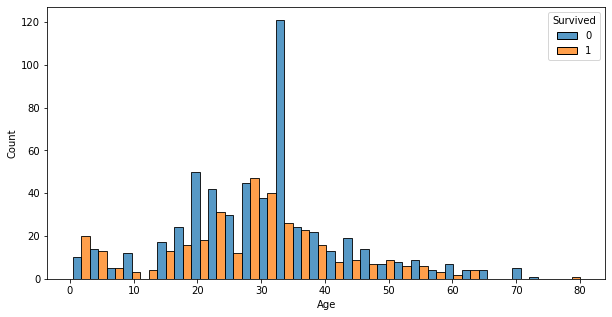

In [49]:
plt.figure(figsize=(10,5))
sns.histplot(x = train["Age"], hue = train["Survived"], multiple='dodge', bins=30)

In [50]:
data = train[(train["Age"]>=0) & (train["Age"]<=5)]
survived = data["Survived"].value_counts()
percent_survived = np.round(survived[1]*100/np.sum(survived), 2)
survived, percent_survived

(1    33
 0    21
 Name: Survived, dtype: int64,
 61.11)

In [51]:
i = 13
data = train[(train["Age"]>=i*5) & (train["Age"]<=(i+1)*5)]
survived = data["Survived"].value_counts()
if len(survived) == 1 and survived.index[0] == 0:
    percent_survived = 0
elif len(survived) == 1 and survived.index[0] == 1:
    percent_survived = 1
else:
    percent_survived = np.round(survived[1]*100/np.sum(survived), 2)
survived, percent_survived

(0    6
 Name: Survived, dtype: int64,
 0)

In [52]:
def plot_by_age(age_muliple):
    age = {}
    i=0
    while True:
        if i*age_muliple > train["Age"].max():
            break
        data = train[(train["Age"]>=i*age_muliple) & (train["Age"]<=(i+1)*age_muliple)]
        survived = data["Survived"].value_counts()
        if len(survived) == 1 and survived.index[0] == 0:
            percent_survived = 0
        elif len(survived) == 1 and survived.index[0] == 1:
            percent_survived = "100"
        elif len(survived) == 0:
            pass
        else:
            percent_survived = np.round(survived[1]*100/np.sum(survived), 2)
        age[f"Age {i*age_muliple}-{(i+1)*age_muliple}"] = np.float(percent_survived)
        i+=1
    pd.DataFrame(age, index=["Survived Percent"]).T.iplot(title = f"Survival by Age", xTitle = "Age", yTitle = "Percentage of Passangers")

In [53]:
plot_by_age(5)

In [54]:
plot_by_age(3)

In [55]:
plot_by_age(10)

In [56]:
plot_by_age(1)

The above plot shows that the passangers who were very young (age < 3) were more likely to survive or the passangers who were age betwee 10-15 were more likely to survive. Also, the older person (age > 60) were more likely to survive.

### SibSp and Parch

In [57]:
hist_by_column_perc("SibSp")

In [58]:
hist_by_column_perc("Parch")

So, a person with 1 or 2 siblings or spouse or parents are more likely to survive.

We create a new column called `FamilySize` which is the sum of SibSp and Parch.

In [59]:
train["FamilySize"] = train["SibSp"] + train["Parch"] + 1
test["FamilySize"] = test["SibSp"] + test["Parch"] + 1

In [60]:
train["FamilySize"].value_counts()

1     537
2     161
3     102
4      29
6      22
5      15
7      12
11      7
8       6
Name: FamilySize, dtype: int64

In [61]:
hist_by_column("FamilySize")

In [62]:
hist_by_column_perc("FamilySize")

If family size is large, chances of survival is lower and lower. Furthermore, a person with no family members is also less likely to survive. The most likely to survive is a person with 3, 2 or  1 family member in that order.

### Fare

In [63]:
train["Fare"].describe()

count    891.000000
mean      32.204208
std       49.693429
min        0.000000
25%        7.910400
50%       14.454200
75%       31.000000
max      512.329200
Name: Fare, dtype: float64

<AxesSubplot:xlabel='Survived', ylabel='Fare'>

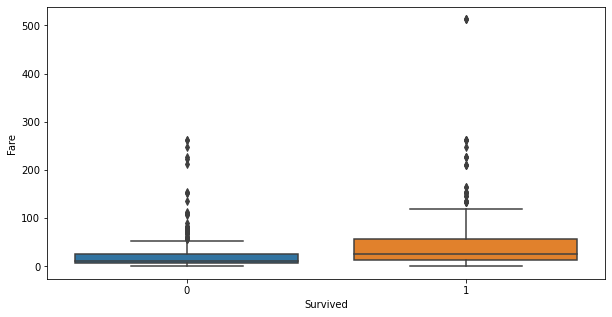

In [64]:
plt.figure(figsize=(10,5))
sns.boxplot(x="Survived", y="Fare", data=train)

First things, which is clear from the boxplot is that the passengers with higher fare were more likely to survive.Let's try to see just how likely they are?

<AxesSubplot:xlabel='Fare'>

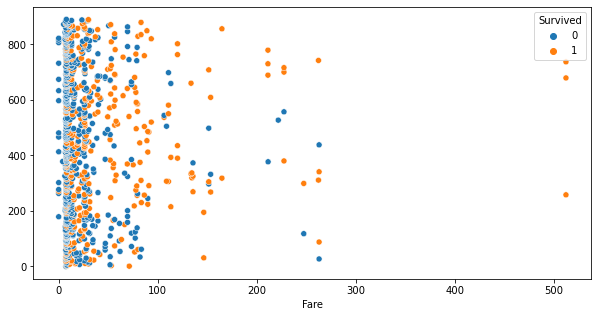

In [65]:
plt.figure(figsize=(10,5))
sns.scatterplot(x = train["Fare"], y = np.arange(len(train["Fare"])), hue = train["Survived"])

In [66]:
def plot_by_fare(fare_multiple,train = train):
    fare = {}
    i=0
    while True:
        if i*fare_multiple > train["Fare"].max():
            break
        data = train[(train["Fare"]>=i*fare_multiple) & (train["Fare"]<=(i+1)*fare_multiple)]
        survived = data["Survived"].value_counts()
        if len(survived) == 1 and survived.index[0] == 0:
            percent_survived = 0
        elif len(survived) == 1 and survived.index[0] == 1:
            percent_survived = "100"
        elif len(survived) == 0:
            pass
        else:
            percent_survived = np.round(survived[1]*100/np.sum(survived), 2)
        fare[f"Fare {i*fare_multiple}-{(i+1)*fare_multiple}"] = np.float(percent_survived)
        i+=1
    pd.DataFrame(fare, index=["Survived Percent"]).T.iplot(title = f"Survival by Fare", xTitle = "Fare", yTitle = "Percentage of Passangers")

In [67]:
plot_by_fare(10)

It seems there are some outliers in the fare column. Let's remove them.

In [68]:
(train["Fare"]>300).sum()

3

There are just three passengers with fare > 300. We'll remove them while plotting the histogram.

In [69]:
train[(train["Fare"]>300)]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title,Ticket_first_letter,Cabin_First,FamilySize
258,259,1,1,"Ward, Miss. Anna",1,35.0,0,0,PC 17755,512.3292,None,C,Miss,X,N,1
679,680,1,1,"Cardeza, Mr. Thomas Drake Martinez",0,36.0,0,1,PC 17755,512.3292,B51 B53 B55,C,Dr,X,B,2
737,738,1,1,"Lesurer, Mr. Gustave J",0,35.0,0,0,PC 17755,512.3292,B101,C,Mr,X,B,1


All these three passengers survived.

In [70]:
train_temp = train[(train["Fare"]<300)]

In [71]:
plot_by_fare(10,train_temp)

This again confirms our hypothesis that the passengers with higher fare were more likely to survive. There are some outliers, but overall result is still good.

In [72]:
plot_by_fare(30,train_temp)

In [73]:
numerical_cols

Index(['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare'], dtype='object')

This completes our EDA and Feature Engineering.

Before we move to model creation, let's drop the redundant columns and use one-hot encoding for the categorical features.

## Preprocessing

### Dropping the Redundant Columns

In [74]:
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title,Ticket_first_letter,Cabin_First,FamilySize
0,1,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,7.2500,None,S,Mr,X,N,2
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,PC 17599,71.2833,C85,C,Mrs,X,C,2
2,3,1,3,"Heikkinen, Miss. Laina",1,26.0,0,0,STON/O2. 3101282,7.9250,None,S,Miss,X,N,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,113803,53.1000,C123,S,Mrs,1,C,2
4,5,0,3,"Allen, Mr. William Henry",0,35.0,0,0,373450,8.0500,None,S,Mr,3,N,1


The redundant columns are: 'PassengerId', 'Name', 'Ticket' and 'Cabin'. Let's drop them.

In [75]:
train = train.drop(["PassengerId", "Name", "Ticket", "Cabin"], axis=1)
test_passangerID = test["PassengerId"]
test = test.drop(["PassengerId", "Name", "Ticket", "Cabin"], axis=1)

We have saved the `PassengerId` column into anothor varaible because we will need it later. Let's save this to a separate csv file.

In [76]:
test_passangerID.to_csv("test_passangerID.csv", index=False)

### One-Hot Encoding

In [77]:
str_features = train.columns[train.dtypes == "object"]
num_features = train.columns[train.dtypes != "object"]

In [78]:
train_final = pd.get_dummies(train, columns=str_features, drop_first=True)

In [79]:
test_final = pd.get_dummies(test, columns=str_features, drop_first=True)

In [80]:
train_final.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,FamilySize,Embarked_Q,Embarked_S,...,Ticket_first_letter_4,Ticket_first_letter_6,Ticket_first_letter_7,Ticket_first_letter_X,Cabin_First_B,Cabin_First_C,Cabin_First_D,Cabin_First_E,Cabin_First_F,Cabin_First_N
0,0,3,0,22.0,1,0,7.2500,2,0,1,...,0,0,0,1,0,0,0,0,0,1
1,1,1,1,38.0,1,0,71.2833,2,0,0,...,0,0,0,1,0,1,0,0,0,0
2,1,3,1,26.0,0,0,7.9250,1,0,1,...,0,0,0,1,0,0,0,0,0,1
3,1,1,1,35.0,1,0,53.1000,2,0,1,...,0,0,0,0,0,1,0,0,0,0
4,0,3,0,35.0,0,0,8.0500,1,0,1,...,0,0,0,0,0,0,0,0,0,1


One final consideration is to standardize the data.

### Standardizing the Data

Standardizing the data is not that important in our case, as only large numerical values are those in Age and Fare columns and they are not that large. Nevertheless, we will standardize the data.

In [81]:
cols_to_standardize = ["Age", "Fare"]
train_final_reduced = train_final.drop(cols_to_standardize, axis=1)
test_final_reduced = test_final.drop(cols_to_standardize, axis=1)

In [82]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
train_standard = scaler.fit_transform(train_final[cols_to_standardize])
test_standard = scaler.fit_transform(test_final[cols_to_standardize])

In [83]:
train_standard = pd.DataFrame(train_standard, columns=cols_to_standardize)
test_standard = pd.DataFrame(test_standard, columns=cols_to_standardize)

In [84]:
train_final = pd.concat([train_final_reduced, train_standard], axis=1)
test_final = pd.concat([test_final_reduced, test_standard], axis=1)

Just for sanity check!

In [85]:
train_final.shape, train.shape

((891, 28), (891, 12))

In [86]:
test_final.shape, test.shape

((418, 27), (418, 11))

In [87]:
train_final.max()

Survived                  1.000000
Pclass                    3.000000
Sex                       1.000000
SibSp                     8.000000
Parch                     6.000000
FamilySize               11.000000
Embarked_Q                1.000000
Embarked_S                1.000000
Title_Master              1.000000
Title_Miss                1.000000
Title_Mr                  1.000000
Title_Mrs                 1.000000
Title_Other               1.000000
Title_Rev                 1.000000
Ticket_first_letter_2     1.000000
Ticket_first_letter_3     1.000000
Ticket_first_letter_4     1.000000
Ticket_first_letter_6     1.000000
Ticket_first_letter_7     1.000000
Ticket_first_letter_X     1.000000
Cabin_First_B             1.000000
Cabin_First_C             1.000000
Cabin_First_D             1.000000
Cabin_First_E             1.000000
Cabin_First_F             1.000000
Cabin_First_N             1.000000
Age                       3.747496
Fare                      9.667167
dtype: float64

In [88]:
test_final.max()

Pclass                    3.000000
Sex                       1.000000
SibSp                     8.000000
Parch                     9.000000
FamilySize               11.000000
Embarked_Q                1.000000
Embarked_S                1.000000
Title_Master              1.000000
Title_Miss                1.000000
Title_Mr                  1.000000
Title_Mrs                 1.000000
Title_Other               1.000000
Title_Rev                 1.000000
Ticket_first_letter_2     1.000000
Ticket_first_letter_3     1.000000
Ticket_first_letter_4     1.000000
Ticket_first_letter_6     1.000000
Ticket_first_letter_7     1.000000
Ticket_first_letter_X     1.000000
Cabin_First_B             1.000000
Cabin_First_C             1.000000
Cabin_First_D             1.000000
Cabin_First_E             1.000000
Cabin_First_F             1.000000
Cabin_First_N             1.000000
Age                       3.540734
Fare                      8.546395
dtype: float64

Everything looks good! Let's move on to the model creation. But before that, let's save the dataframes to csv files.

In [89]:
train_final.to_csv("train_final.csv", index=False)
test_final.to_csv("test_final.csv", index=False)